# Clase 6. Aprendizaje no supervisado y reducción de dimensionalidad



Los temas son:
1. K-Means clustering
2. Gaussian Mixture Models (GMM)
3. Análisis de Componentes Principales (PCA)
4. t-SNE
5. UMAP
6. Autoencoders (con scikit-learn)
7. Detección de anomalías
8. Ejemplo automatizado con PyCaret


In [ ]:
# !pip install umap-learn pycaret

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

## Carga de los datasets
* Cargamos **Iris** y **MNIST (digits)** desde `sklearn.datasets`.
* Escalamos ambos con `StandardScaler` para que los métodos basados en distancias se comporten correctamente.

In [42]:
# Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

scaler = StandardScaler()
X_iris_sc = scaler.fit_transform(X_iris)

print('Iris:', X_iris.shape, 'clases:', np.unique(y_iris))

# MNIST (digits)
digits = load_digits()
X_dig = digits.data
y_dig = digits.target

X_dig_sc = StandardScaler().fit_transform(X_dig)

print('Digitos:', X_dig.shape, 'clases:', np.unique(y_dig))

Iris: (150, 4) clases: [0 1 2]
Digitos: (1797, 64) clases: [0 1 2 3 4 5 6 7 8 9]


* Veamos algunas imágenes del dataset MNIST para tener intuición de qué representa cada muestra:

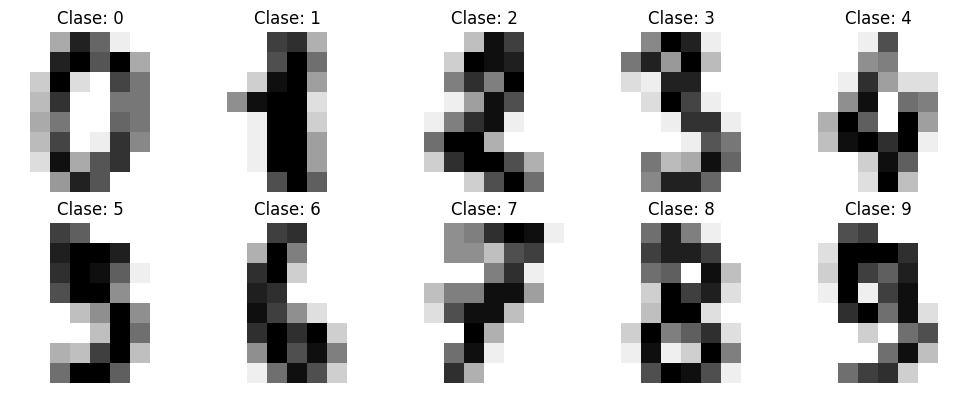

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Clase: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 1. K-Means Clustering
K-Means agrupa los datos en `k` clusters minimizando la suma de distancias al cuadrado entre cada punto y el centroide de su cluster (la *inertia*).

* Para elegir el número óptimo de clusters, una técnica común es el **método del codo** (*elbow method*).
* Aplicaremos K-Means a Iris y graficaremos la inertia en función de `k`.

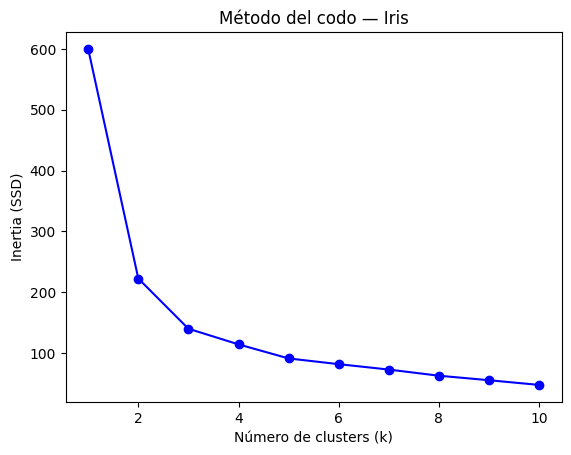

In [7]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_iris_sc)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia (SSD)')
plt.title('Método del codo — Iris')
plt.show()

* Ahora ajustamos K-Means con `k=3` (sabemos que Iris tiene 3 clases).

In [8]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_iris_sc)

print('Silhouette score:', round(silhouette_score(X_iris_sc, labels_kmeans), 3))

Silhouette score: 0.46


* Visualizamos los clusters obtenidos vs las clases reales usando los dos primeros atributos (longitud y ancho del sépalo). Tener presente que es solo una comparación, no esperamos obtener una similaridad perfecta! no es una tarea de clasificación!!

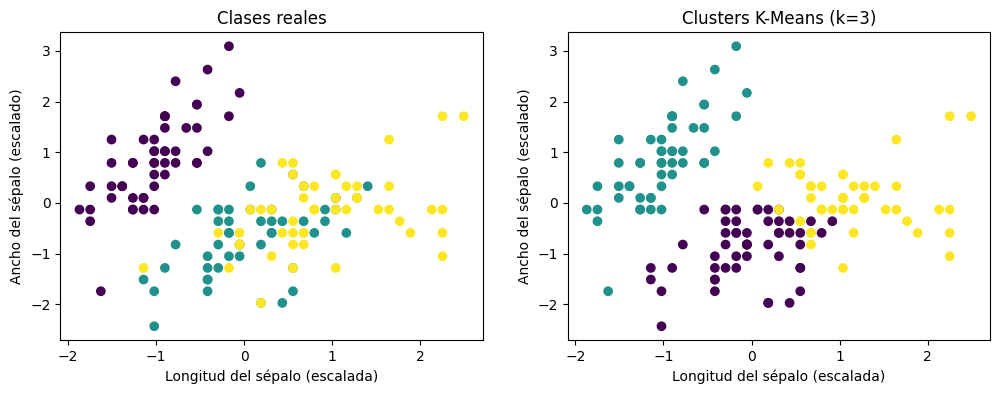

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_iris_sc[:, 0], X_iris_sc[:, 1], c=y_iris, cmap='viridis')
axes[0].set_title('Clases reales')
axes[1].scatter(X_iris_sc[:, 0], X_iris_sc[:, 1], c=labels_kmeans, cmap='viridis')
axes[1].set_title('Clusters K-Means (k=3)')
for ax in axes:
    ax.set_xlabel('Longitud del sépalo (escalada)')
    ax.set_ylabel('Ancho del sépalo (escalado)')
plt.show()

### Ejercicio
* Aplica el método del codo al dataset MNIST. 
*  ¿Qué tan bien recupera las clases reales?

## 2. Gaussian Mixture Models (GMM)
Los GMM modelan los datos como una mezcla de varias distribuciones gaussianas. A diferencia de K-Means:

* GMM produce una asignación **probabilística** (cada punto tiene una probabilidad de pertenecer a cada cluster).
* Permite clusters de **forma elíptica** (no solo esférica como K-Means).
* Para elegir el número de componentes, podemos usar el **BIC** (Bayesian Information Criterion) y **AIC** (Akaike Information Criterion): valores más bajos son mejores.

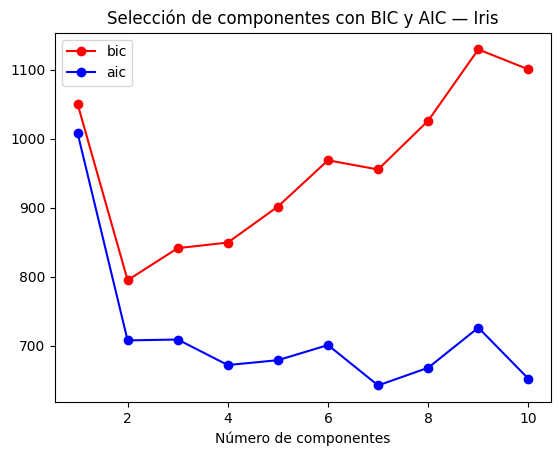

In [10]:
bics = []
aics=[]
K_range = range(1, 11)
for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_iris_sc)
    bics.append(gmm.bic(X_iris_sc))
    aics.append(gmm.aic(X_iris_sc))

plt.plot(K_range, bics, 'ro-',label="bic")
plt.plot(K_range, aics, 'bo-',label="aic")
plt.xlabel('Número de componentes')
plt.legend()
plt.title('Selección de componentes con BIC y AIC — Iris')
plt.show()

In [11]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels_gmm = gmm.fit_predict(X_iris_sc)
probs_gmm = gmm.predict_proba(X_iris_sc)
print('Probabilidades de las primeras 5 muestras:')
print(np.round(probs_gmm[:5], 3))

Probabilidades de las primeras 5 muestras:
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


* Una ventaja interesante de los GMM es que podemos identificar puntos con asignación **incierta** (probabilidad máxima baja). Estos suelen estar en las fronteras entre clusters.

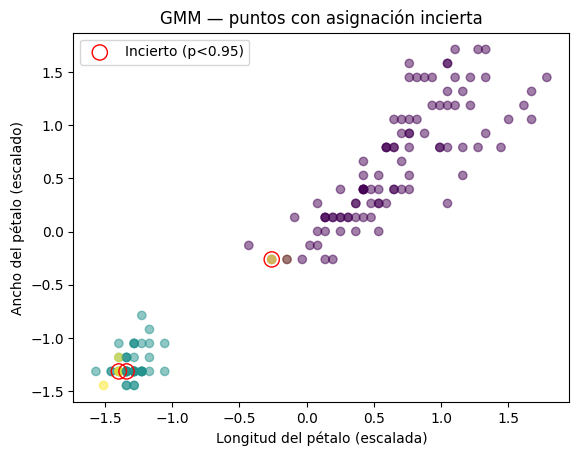

In [12]:
max_prob = probs_gmm.max(axis=1)
uncertain = max_prob < 0.95

plt.scatter(X_iris_sc[:, 2], X_iris_sc[:, 3], c=labels_gmm, cmap='viridis', alpha=0.5)
plt.scatter(X_iris_sc[uncertain, 2], X_iris_sc[uncertain, 3],
            facecolors='none', edgecolors='red', s=120, label='Incierto (p<0.95)')
plt.xlabel('Longitud del pétalo (escalada)')
plt.ylabel('Ancho del pétalo (escalado)')
plt.title('GMM — puntos con asignación incierta')
plt.legend()
plt.show()

### Ejercicio 2
* Compara los resultados (ARI) de K-Means y GMM en Iris. ¿Cuál funciona mejor? 
* Aplica GMM con `n_components=10` a MNIST.
* Prueba diferentes tipos de covarianza (`'full'`, `'tied'`, `'diag'`, `'spherical'`). ¿Cómo afecta esto a los resultados?

## 3. Análisis de Componentes Principales (PCA)
PCA es una técnica **lineal** que encuentra nuevos ejes (componentes principales) que maximizan la varianza de los datos.

* Empezaremos con Iris reduciendo a 2D para visualización.
* Luego veremos PCA en MNIST para entender la **varianza explicada acumulada**.

Varianza explicada por cada PC: [0.73  0.229]
Total acumulada: 0.958


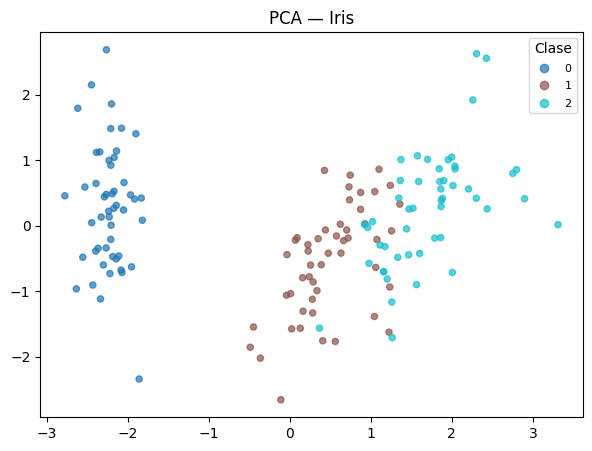

In [13]:
def plot_projection(X2d, y, title=''):
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(X2d[:, 0], X2d[:, 1], c=y, cmap='tab10', alpha=0.7, s=20)
    handles, labels = scatter.legend_elements()
    ax.legend(handles, labels, loc='best', title='Clase', fontsize=8)
    ax.set_title(title)
    plt.show()

pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_sc)
print('Varianza explicada por cada PC:', np.round(pca_iris.explained_variance_ratio_, 3))
print('Total acumulada:', round(pca_iris.explained_variance_ratio_.sum(), 3))
plot_projection(X_iris_pca, y_iris, 'PCA — Iris')

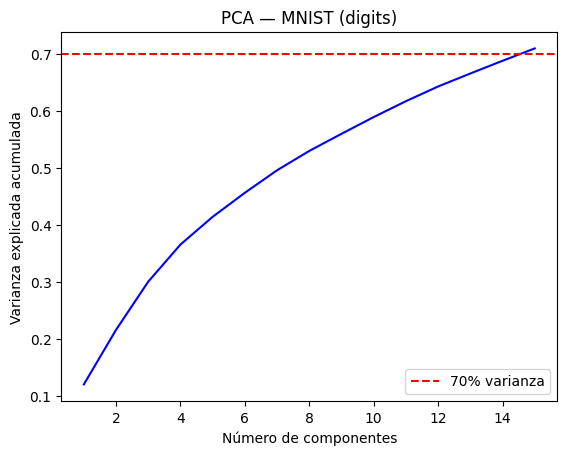

Componentes necesarios para retener el 70% de la varianza: 15


In [14]:
# PCA en MNIST: varianza explicada acumulada
pca_full = PCA(0.7).fit(X_dig_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cumvar)+1), cumvar, 'b-')
plt.axhline(0.7, color='red', linestyle='--', label='70% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — MNIST (digits)')
plt.legend()
plt.show()

n70 = np.argmax(cumvar >= 0.7) + 1
print(f'Componentes necesarios para retener el 70% de la varianza: {n70}')

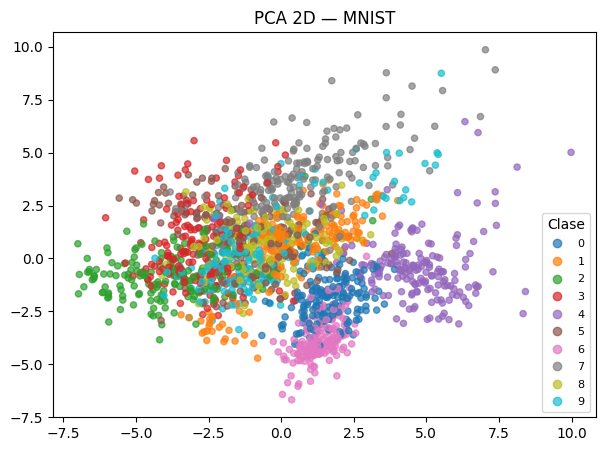

In [15]:
# Visualizamos MNIST en 2D con PCA
X_dig_pca = PCA(n_components=2).fit_transform(X_dig_sc)
plot_projection(X_dig_pca, y_dig, 'PCA 2D — MNIST')

### Ejercicio 3
* En MNIST, ¿cuántos componentes se necesitan para retener el 90% de la varianza? ¿Y el 99%?
* Aplica K-Means en el espacio PCA reducido (con los componentes que retienen 95% de la varianza) sobre MNIST. ¿Mejora o empeora el ARI respecto a aplicarlo sobre los datos originales?

## 4. t-SNE
t-SNE es una técnica **no lineal** que preserva las relaciones de **vecindad local**. Es excelente para visualización pero:

* No es determinista (depende del `random_state`).
* Es más lenta que PCA.
* No se puede usar directamente para transformar datos nuevos (no tiene método `transform`).
* El parámetro **`perplexity`** controla cuántos vecinos se consideran (típicamente entre 5 y 50).

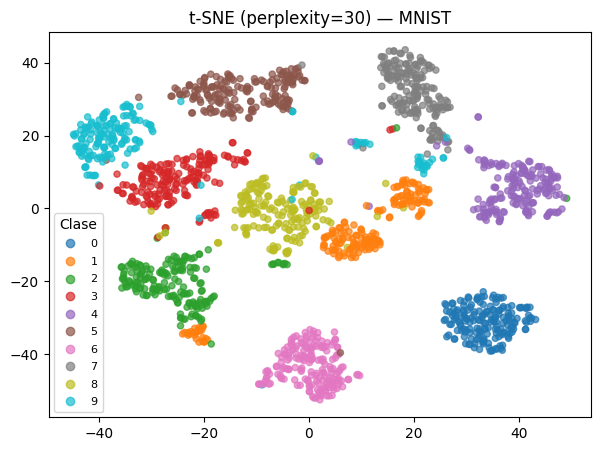

In [16]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_dig_tsne = tsne.fit_transform(X_dig_sc)
plot_projection(X_dig_tsne, y_dig, 't-SNE (perplexity=30) — MNIST')

### Ejercicio 4
* Prueba `perplexity` en valores 5, 30 y 100 sobre MNIST. ¿Cómo cambia la separación entre clusters?
* Aplica t-SNE a Iris. ¿Qué diferencia ves respecto a PCA?

## 5. UMAP
UMAP es similar a t-SNE, pero:

* Es **más rápido**.
* Suele preservar mejor la **estructura global** además de la local.
* Sí permite proyectar datos nuevos con `transform()`.
* Sus parámetros clave son `n_neighbors` (similar a perplexity) y `min_dist` (distancia mínima entre puntos en la proyección).

c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


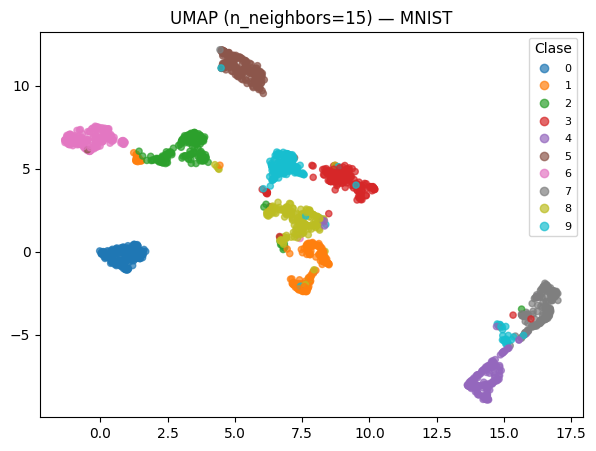

In [17]:
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_dig_umap = umap_model.fit_transform(X_dig_sc)
plot_projection(X_dig_umap, y_dig, 'UMAP (n_neighbors=15) — MNIST')

### Ejercicio 5
* Compara visualmente las proyecciones de PCA, t-SNE y UMAP sobre MNIST. ¿Cuál separa mejor las clases?

## 6. Autoencoder (con scikit-learn)
Usaremos `MLPRegressor` para implementar un autoencoder simple. La red aprende a reconstruir su entrada (`fit(X, X)`) y la capa oculta más pequeña (el **bottleneck**) genera una representación comprimida de los datos.

* Entrenamos un autoencoder con bottleneck de 2 neuronas para visualización.
* La función `encoder` extrae la salida de esa capa oculta.

In [29]:
ae = MLPRegressor(hidden_layer_sizes=(64, 2, 64), activation='relu',
                  max_iter=1000, random_state=42,learning_rate_init=0.01)
ae.fit(X_dig_sc, X_dig_sc)
print('Loss final:', round(ae.loss_, 4))

Loss final: 0.2236


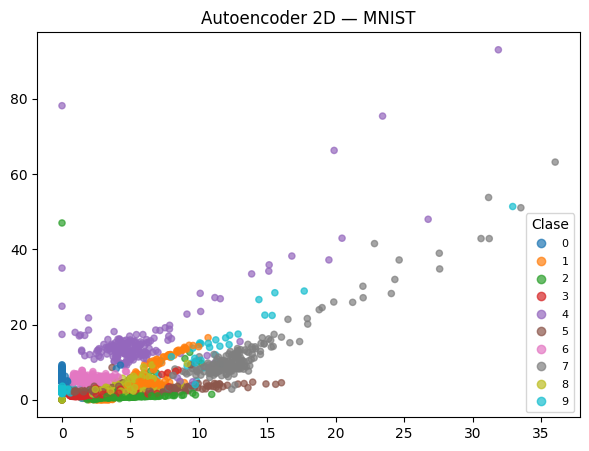

In [34]:
def encoder(X, model, bottleneck_layer=1):
    """Propaga X hasta la capa bottleneck del MLPRegressor."""
    activation = np.asarray(X)
    for i in range(bottleneck_layer + 1):
        activation = activation @ model.coefs_[i] + model.intercepts_[i]
        if i < bottleneck_layer: 
            activation = np.maximum(activation,0 )
    activation = np.maximum(activation, 0)
    return activation

X_dig_ae = encoder(X_dig_sc, ae, bottleneck_layer=1)
plot_projection(X_dig_ae, y_dig, 'Autoencoder 2D — MNIST')

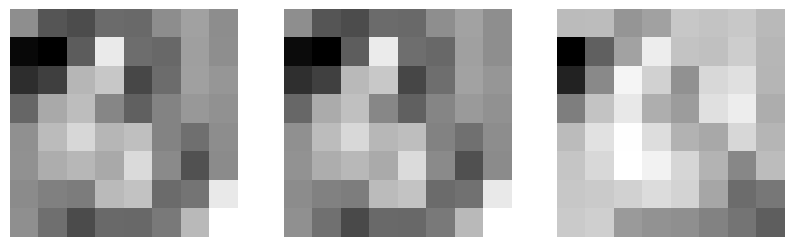

In [35]:
rng = np.random.default_rng()
y_hat = ae.predict(rng.random((3, 64)))
fig, axs = plt.subplots(1, 3, figsize=(10, 7))
for i in range(3):
    axs.flat[i].imshow(y_hat[i].reshape(8, 8), cmap="binary")
    axs.flat[i].axis("off")

## 7. Detección de anomalías
La detección de anomalías (u *outlier detection*) busca identificar muestras que **se desvían significativamente** del resto. Veremos 4 métodos clásicos de scikit-learn:
* **Autoencoders** - entrenar solo con las clases normales (digitos 0) y buscar imagenes anomalas (1,2,3)
* **Isolation Forest** — basado en árboles, aísla los puntos anómalos con pocos cortes aleatorios.
* **One-Class SVM** — aprende una frontera que envuelve los datos "normales".
* **Local Outlier Factor (LOF)** — compara la densidad local de un punto con la de sus vecinos.

Para ilustrarlos, contaminaremos Iris con puntos generados aleatoriamente y veremos qué métodos los detectan.

c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


ROC AUC  test set: 0.999


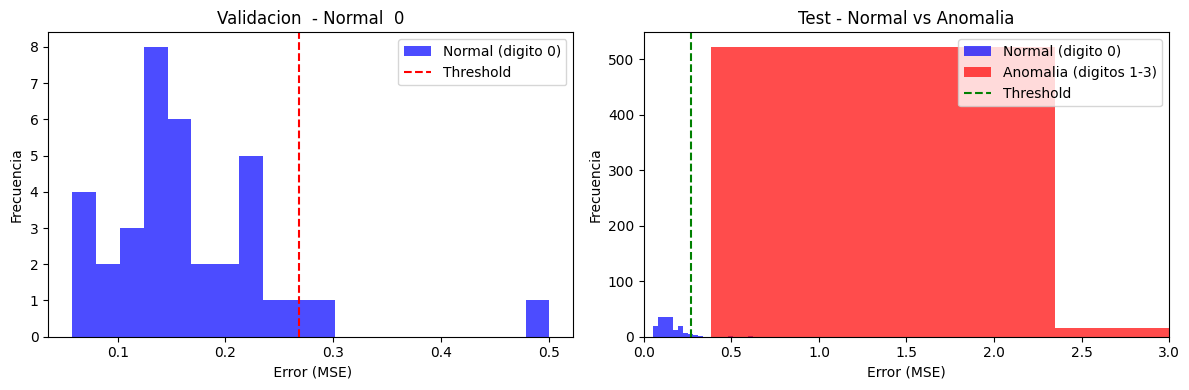

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Seleccionar 'normal' clase (e.g., digito 0)
normal_class = 0
##Aqui recordemos que el scaler se debe aplicar solo al conjunto de entrenamiento. Por ahora ignoremos el data leakage generado en este paso.
X_normal = X_dig_sc[y_dig == normal_class]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
model = MLPRegressor(hidden_layer_sizes=(64, 32),
                     activation='relu',
                     solver='adam',
                     random_state=42,
                     max_iter=100,
                     verbose=False)


model.fit(X_train, X_train)

def reconstruction_error(model, X):
    pred = model.predict(X)
    return np.mean((pred - X) ** 2, axis=1)

anomaly_classes = [1, 2, 3]
mask_anomaly = np.isin(y_dig, anomaly_classes)
mask_normal = (y_dig == normal_class)

# Combinar normales + anomalías específicas para test
mask_test = mask_normal | mask_anomaly
X_test = X_dig_sc[mask_test]
y_test = y_dig[mask_test]
val_errors = reconstruction_error(model, X_val)

y_test_binary = (y_test == normal_class).astype(int)
test_errors = reconstruction_error(model, X_test)

auc = roc_auc_score(y_test_binary, -test_errors)
print(f"ROC AUC  test set: {auc:.3f}")

threshold = np.percentile(val_errors, 95)
pred_anomaly = test_errors > threshold


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(val_errors, bins=20, alpha=0.7, label=f'Normal (digito {normal_class})', color='blue')
axes[0].set_xlabel(' Error (MSE)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Validacion  - Normal  {normal_class}')
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Threshold')
axes[0].legend()

# Test set errors (split by normal vs anomalous)
normal_test_errors = test_errors[y_test_binary == 1]
anomaly_test_errors = test_errors[y_test_binary == 0]

axes[1].hist(normal_test_errors, bins=20, alpha=0.7, label=f'Normal (digito {normal_class})', color='blue')
axes[1].hist(anomaly_test_errors, bins=20, alpha=0.7, label=f'Anomalia (digitos 1-3)', color='red')
axes[1].set_xlabel('Error (MSE)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Test - Normal vs Anomalia')
axes[1].axvline(threshold, color='green', linestyle='--', label=f'Threshold')
axes[1].legend()
axes[1].set_xlim(0,3)
plt.tight_layout()
plt.show()


In [40]:
# Generamos 15 outliers aleatorios y los añadimos a Iris
rng = np.random.RandomState(42)
outliers = rng.uniform(low=-4, high=4, size=(15, X_iris_sc.shape[1]))
X_contam = np.vstack([X_iris_sc, outliers])
y_true = np.hstack([np.ones(len(X_iris_sc)), -np.ones(len(outliers))])  # 1=normal, -1=anomalía

print('Tamaño total:', X_contam.shape, '| Anomalías reales:', (y_true == -1).sum())

Tamaño total: (165, 4) | Anomalías reales: 15


In [37]:
models = {
    'IsolationForest': IsolationForest(contamination=0.1, random_state=42),
    'OneClassSVM': OneClassSVM(gamma='auto', nu=0.1),
    'LocalOutlierFactor': LocalOutlierFactor(n_neighbors=20, contamination=0.1)
}

results = {}
for name, model in models.items():
    if name == 'LocalOutlierFactor':
        pred = model.fit_predict(X_contam)
    else:
        model.fit(X_contam)
        pred = model.predict(X_contam)
    results[name] = pred
    detected = ((pred == -1) & (y_true == -1)).sum()
    false_alarms = ((pred == -1) & (y_true == 1)).sum()
    print(f'{name}: anomalías detectadas={detected}/15, falsos positivos={false_alarms}')

IsolationForest: anomalías detectadas=15/15, falsos positivos=2
OneClassSVM: anomalías detectadas=9/15, falsos positivos=8
LocalOutlierFactor: anomalías detectadas=14/15, falsos positivos=3


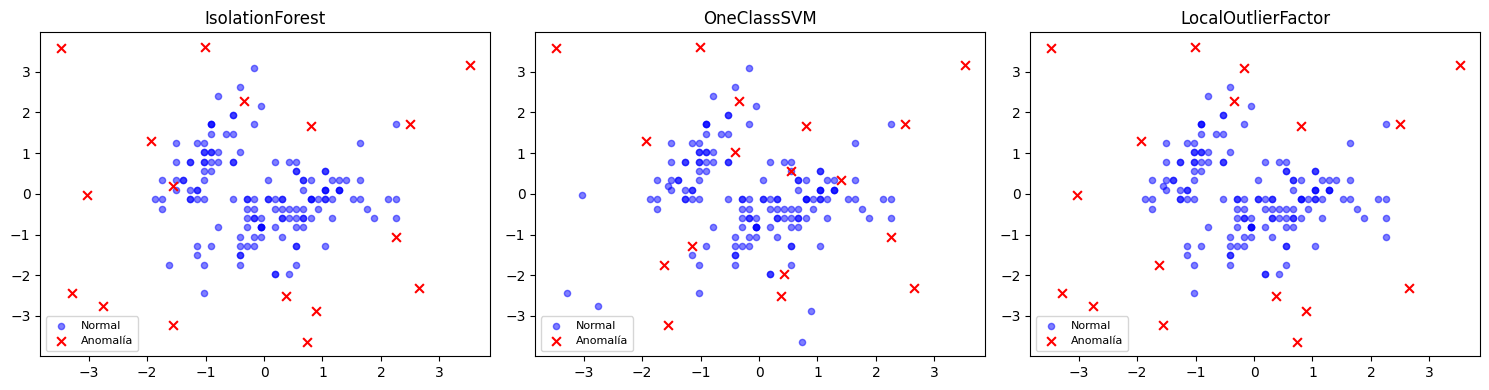

In [38]:
# Visualizamos sobre las dos primeras dimensiones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, results.items()):
    ax.scatter(X_contam[pred == 1, 0], X_contam[pred == 1, 1],
               c='blue', s=20, alpha=0.5, label='Normal')
    ax.scatter(X_contam[pred == -1, 0], X_contam[pred == -1, 1],
               c='red', s=40, marker='x', label='Anomalía')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Ejercicio 7
* Varía el parámetro `contamination` (proporción esperada de anomalías) entre 0.05 y 0.2. ¿Cómo afecta al número de detecciones y falsos positivos?
* Aplica los tres métodos a MNIST tratando una clase específica (e.g. el dígito 1) como "normal" y el resto como anomalías. ¿Qué método funciona mejor?

## 8. Ejemplo automatizado con PyCaret


In [37]:
from pycaret.clustering import setup, create_model, assign_model, plot_model, models

df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)

# 1) setup: el parámetro normalize=True aplica StandardScaler internamente
clu_setup = setup(data=df_iris, normalize=True, session_id=42, verbose=False)

In [38]:
# Lista de modelos disponibles
models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch


In [39]:
# 2) Crear un modelo K-Means con 3 clusters
kmeans_pc = create_model('kmeans', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4799,157.3602,0.7894,0,0,0


In [41]:
# 3) Asignar las etiquetas al dataset
df_clustered = assign_model(kmeans_pc)
df_clustered.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,Cluster 1
1,4.9,3.0,1.4,0.2,Cluster 2
2,4.7,3.2,1.3,0.2,Cluster 2
3,4.6,3.1,1.5,0.2,Cluster 2
4,5.0,3.6,1.4,0.2,Cluster 1


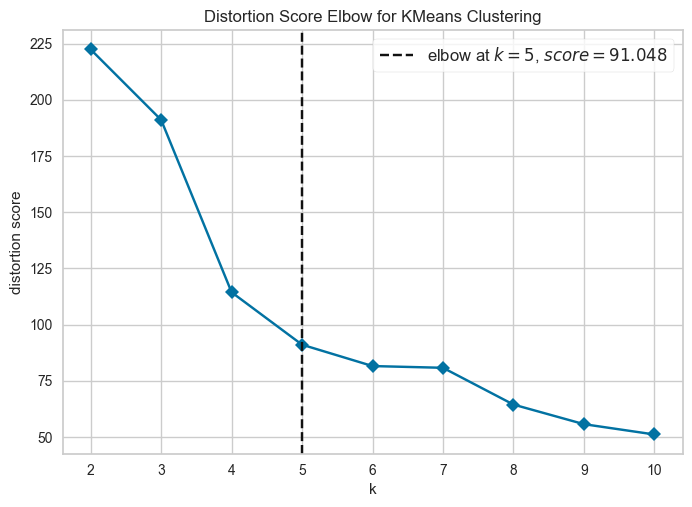

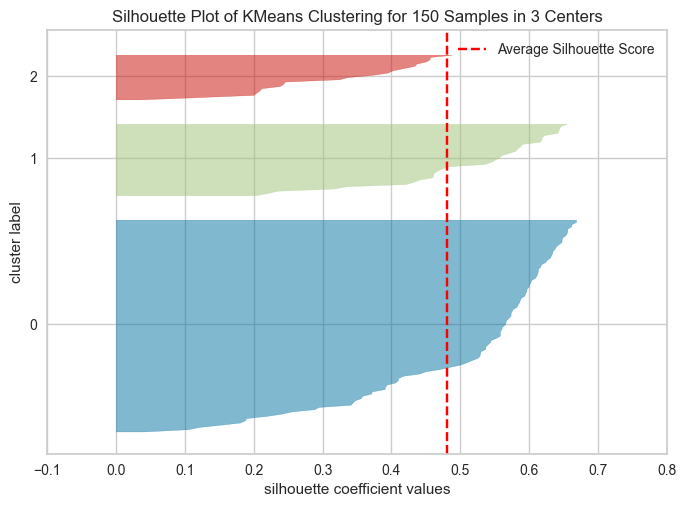

In [42]:
# Gráficos integrados de PyCaret
plot_model(kmeans_pc, plot='cluster')   # proyección 2D con PCA
plot_model(kmeans_pc, plot='elbow')     # método del codo
plot_model(kmeans_pc, plot='silhouette') # diagrama de silueta

* PyCaret también tiene un módulo de **detección de anomalías** muy similar:

In [26]:
from pycaret.anomaly import setup as ad_setup, create_model as ad_create, assign_model as ad_assign

ad_setup(data=df_iris, normalize=True, session_id=42, verbose=False)
iforest = ad_create('iforest')          # Isolation Forest
df_anom = ad_assign(iforest)
print('Anomalías detectadas:', (df_anom['Anomaly'] == 1).sum())
df_anom.head()

Anomalías detectadas: 8


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Anomaly,Anomaly_Score
0,5.1,3.5,1.4,0.2,0,-0.183079
1,4.9,3.0,1.4,0.2,0,-0.157089
2,4.7,3.2,1.3,0.2,0,-0.136576
3,4.6,3.1,1.5,0.2,0,-0.127722
4,5.0,3.6,1.4,0.2,0,-0.172064


### Ejercicio 8
* Usando PyCaret, compara K-Means con `num_clusters` desde 2 hasta 6. ¿Cuál ofrece la mejor silueta?
* Crea un modelo `'gmm'` con PyCaret y compáralo con `'kmeans'` usando los gráficos integrados.
* En el módulo de anomalías, prueba diferentes algoritmos (`'iforest'`, `'knn'`, `'lof'`, `'svm'`) y compara cuántas anomalías detecta cada uno.